<a href="https://colab.research.google.com/github/truongkendy/ai4se/blob/main/RepairLLaMa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1
!pip install -q -U transformers peft accelerate bitsandbytes datasets sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.7 MB/s eta 0:00:00


This first cell installs necessary Python libraries: `transformers`, `peft`, `accelerate`, `bitsandbytes`, `datasets`, and `sentencepiece`. These are commonly used for working with large language models, especially for fine-tuning (PEFT), efficient loading (accelerate, bitsandbytes), and text processing (datasets, sentencepiece).

In [2]:
#2
from google.colab import drive
drive.mount('/content/drive')
import os
WORK = "/content/drive/MyDrive/repairllama_run"; os.makedirs(WORK, exist_ok=True)

%cd /content
![ -d repairllama ] || git clone --depth 1 https://github.com/ASSERT-KTH/repairllama
![ -d human-eval-java ] || git clone --depth 1 https://github.com/ASSERT-KTH/human-eval-java

Mounted at /content/drive
/content
Cloning into 'repairllama'...
remote: Enumerating objects: 4120, done.
remote: Counting objects: 100% (4120/4120), done.
remote: Compressing objects: 100% (3314/3314), done.
remote: Total 4120 (delta 973), reused 3928 (delta 805), pack-reused 0 (from 0)
Receiving objects: 100% (4120/4120), 52.11 MiB | 14.37 MiB/s, done.
Resolving deltas: 100% (973/973), done.
Updating files: 100% (6819/6819), done.
Cloning into 'human-eval-java'...
remote: Enumerating objects: 1021, done.
remote: Counting objects: 100% (1021/1021), done.
remote: Compressing objects: 100% (550/550), done.
remote: Total 1021 (delta 473), reused 1006 (delta 465), pack-reused 0 (from 0)
Receiving objects: 100% (1021/1021), 995.16 KiB | 25.52 MiB/s, done.
Resolving deltas: 100% (473/473), done.


In [3]:
#3
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

BASE = "codellama/CodeLlama-7b-hf"
tok = AutoTokenizer.from_pretrained(BASE)
bnb = BitsAndBytesConfig(load_in_8bit=True)
base = AutoModelForCausalLM.from_pretrained(BASE, quantization_config=bnb, device_map="auto")
model = PeftModel.from_pretrained(base, "/content/repairllama/repairllama-lora")

model.eval()
print("loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/637 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

loaded


In [4]:
model.config.pad_token = tok.pad_token = tok.unk_token

In [5]:
#4
def build_ir4(prefix: str, buggy_lines: str, suffix: str) -> str:
    commented = "\n".join("// " + l for l in buggy_lines.splitlines())
    return f"{prefix}\n// buggy code\n{commented}\n<FILL_ME>\n{suffix}"

@torch.no_grad()
def generate_patches(prompt: str, n: int = 10, max_new=256):
    ids = tok(prompt, return_tensors="pt")["input_ids"].to(model.device)
    out = model.generate(ids, max_new_tokens=max_new, do_sample=True,
                         temperature=0.8, top_p=0.95, num_return_sequences=n,
                         pad_token_id=tok.eos_token_id)
    fills = tok.batch_decode(out[:, ids.shape[1]:], skip_special_tokens=True)
    return [f.split("<EOT>")[0].rstrip() for f in fills]

In [6]:
#5
import json, os
ROOT = "/content/human-eval-java"
WORK = "/content/drive/MyDrive/repairllama_run"; os.makedirs(WORK, exist_ok=True)

DATA = json.load(open(f"{ROOT}/humaneval-java-sf.json"))
print(len(DATA), "bugs |", list(DATA)[:3])

def load_bug(name):
    e = DATA[name]
    path = f"{ROOT}/src/main/java/humaneval/buggy/{name}.java"
    lines = open(path).read().split("\n")
    b, en = e["begin"], e["end"]
    return {
        "name": name, "path": path,
        "prefix": "\n".join(lines[:b-1]),
        "suffix": "\n".join(lines[en:]),
        "buggy_fn": e["buggy"], "fix_fn": e["fix"],
        "orig_file": "\n".join(lines),
        "test_fqn": f"humaneval.TEST_{name}",
        "test_src": f"{ROOT}/src/test/java/humaneval/TEST_{name}.java",
    }

SUBSET = sorted(DATA.keys())
json.dump(SUBSET, open(f"{WORK}/subset.json", "w"))
print(len(SUBSET), "bug |", SUBSET[:5])

163 bugs | ['DECODE_SHIFT', 'ANTI_SHUFFLE', 'FIB4']
163 bug | ['ADD', 'ADD_ELEMENTS', 'ADD_EVEN_AT_ODD', 'ALL_PREFIXES', 'ANTI_SHUFFLE']


In [7]:
#6
import subprocess, tempfile, shutil, torch
CP = f"{ROOT}/lib/junit4-4.12.jar:{ROOT}/lib/hamcrest-all-1.3.jar"

def split_region(buggy_region):
    bl = buggy_region.rstrip("\n").split("\n")
    return bl[0], "\n".join(bl[1:-1]), bl[-1]

def make_ir4_prompt(prefix, buggy_region, suffix):
    head, inner, tail = split_region(buggy_region)

    return f"{prefix}\n{head}\n<FILL_ME>\n{tail}\n{suffix}"

@torch.no_grad()
def gen_fills_ir4(prefix, buggy_region, suffix, n=5, max_new=256):
    prompt = make_ir4_prompt(prefix, buggy_region, suffix)
    inputs = tok(prompt, return_tensors="pt")
    ilen = inputs["input_ids"].shape[1]
    out = model.generate(
        input_ids=inputs["input_ids"].to(model.device),
        max_new_tokens=max_new, num_return_sequences=n,
        num_beams=max(n, 5), early_stopping=True,
        pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id,
    )
    fills = tok.batch_decode(out[:, ilen:], skip_special_tokens=True,
                             clean_up_tokenization_spaces=False)
    return [_clip(f) for f in fills]

def _clip(fill):

    depth = 0
    for i, ch in enumerate(fill):
        if ch == "{": depth += 1
        elif ch == "}":
            if depth == 0:
                return fill[:i].rstrip()
            depth -= 1
    return fill.rstrip()

def patched_file(bug, fill):
    e = DATA[bug["name"]]
    region = "\n".join(bug["orig_file"].split("\n")[e["begin"]-1 : e["end"]])
    head, _, tail = split_region(region)

    return bug["prefix"] + "\n" + head + "\n" + fill + "\n" + tail + "\n" + bug["suffix"]

def compile_and_test(bug, fill):
    work = tempfile.mkdtemp()
    try:
        open(bug["path"], "w").write(patched_file(bug, fill))
        cj = subprocess.run(["javac", "-cp", CP, "-d", work, bug["path"], bug["test_src"]],
                            capture_output=True, text=True)
        if cj.returncode != 0:
            return "compile_error"
        rt = subprocess.run(["java", "-cp", f"{work}:{CP}", "org.junit.runner.JUnitCore", bug["test_fqn"]],
                            capture_output=True, text=True, timeout=60)
        return "pass" if rt.returncode == 0 else "fail"
    except subprocess.TimeoutExpired:
        return "timeout"
    finally:
        open(bug["path"], "w").write(bug["orig_file"])
        shutil.rmtree(work, ignore_errors=True)

In [8]:
#7
import json, os
from tqdm import tqdm

WORK = "/content/drive/MyDrive/repairllama_run"; os.makedirs(WORK, exist_ok=True)
FILLS = f"{WORK}/fills.json"

fills = json.load(open(FILLS)) if os.path.exists(FILLS) else {}
SUBSET = json.load(open(f"{WORK}/subset.json"))
todo = [n for n in SUBSET if n not in fills]

print(f"Đã có {len(fills)} | còn {len(todo)} cần sinh")

for i, name in enumerate(tqdm(todo)):
    bug = load_bug(name); e = DATA[name]
    lines = bug["orig_file"].split("\n")
    buggy_region = "\n".join(lines[e["begin"]-1 : e["end"]])
    fills[name] = gen_fills_ir4(bug["prefix"], buggy_region, bug["suffix"], n=4, max_new=128)
    if (i + 1) % 5 == 0 or i == len(todo) - 1:
        json.dump(fills, open(FILLS, "w"))
json.dump(fills, open(FILLS, "w"))
print(f"Xong pha 1: {len(fills)}/{len(DATA)} bug đã có patch (IR4) → {FILLS}")

Đã có 0 | còn 163 cần sinh


  0%|          | 0/163 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
100%|██████████| 163/163 [1:17:17<00:00, 28.45s/it]

Xong pha 1: 163/163 bug đã có patch (IR4) → /content/drive/MyDrive/repairllama_run/fills.json


In [9]:
#8
import json, os
from tqdm import tqdm

WORK = "/content/drive/MyDrive/repairllama_run"
FILLS = f"{WORK}/fills.json"
RESULTS = f"{WORK}/heval_results.json"

fills = json.load(open(FILLS))
results = json.load(open(RESULTS)) if os.path.exists(RESULTS) else {}
todo = [n for n in fills if n not in results]
print(f"Đã chấm {len(results)} | còn {len(todo)}")

for i, name in enumerate(tqdm(todo)):
    bug = load_bug(name)
    verdict = "fail"
    for fill in fills[name]:
        v = compile_and_test(bug, fill)
        if v == "pass":
            verdict = "plausible"; break
    results[name] = verdict
    if (i + 1) % 10 == 0 or i == len(todo) - 1:
        json.dump(results, open(RESULTS, "w"))
json.dump(results, open(RESULTS, "w"))

from collections import Counter
c = Counter(results.values())
print(f"\nPlausible: {c['plausible']}/{len(results)} | chi tiết: {dict(c)}")
print("→ Lọc tay 'plausible' ra 'correct'. Mốc paper IR4xOR2: 109/162.")

Đã chấm 0 | còn 163


100%|██████████| 163/163 [11:46<00:00,  4.33s/it]


Plausible: 46/163 | chi tiết: {'plausible': 46, 'fail': 117}
→ Lọc tay 'plausible' ra 'correct'. Mốc paper IR4xOR2: 109/162.


In [10]:
def report(k, n, label=""):
    pct = 100 * k / n if n else 0
    print(f"{label}: {k}/{n} = {pct:.1f}%")

from collections import Counter
results = json.load(open("/content/drive/MyDrive/repairllama_run/heval_results.json"))
c = Counter(results.values())
report(c["plausible"], len(results), label="IR3 perfect-FL")

IR3 perfect-FL: 46/163 = 28.2%


In [11]:
#11: FL boundary
def perturb_span(begin, end, n_lines, mode, k):
    if mode == "perfect": return begin, end
    if mode == "offset":  return max(1, begin+k), min(n_lines, end+k)
    if mode == "over":    return max(1, begin-k), min(n_lines, end+k)
    if mode == "under":
        nb, ne = min(end, begin+k), max(begin, end-k)
        return (nb, ne) if nb <= ne else (begin, begin)
    raise ValueError(mode)

def build_ir4_noisy(name, mode, k):
    e = DATA[name]
    lines = open(f"{ROOT}/src/main/java/humaneval/buggy/{name}.java").read().split("\n")
    b, en = perturb_span(e["begin"], e["end"], len(lines), mode, k)
    prefix = "\n".join(lines[:b-1]); suffix = "\n".join(lines[en:])
    region = "\n".join(lines[b-1:en])
    head, inner, tail = split_region(region)
    return f"{prefix}\n{head}", f"{tail}\n{suffix}"

In [12]:
#12: NLL measure
import torch
@torch.no_grad()
def fix_nll_from_prompt(prefix, suffix, fix_inner):

    prompt = f"{prefix}\n<FILL_ME>\n{suffix}"
    enc = tok(prompt, return_tensors="pt").to(model.device)
    tgt = tok(fix_inner, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
    ids = torch.cat([enc.input_ids, tgt], dim=1)
    labels = ids.clone(); labels[:, :enc.input_ids.shape[1]] = -100
    loss = model(ids, labels=labels).loss.item(); torch.cuda.empty_cache()
    return loss

In [13]:
#Cell 13: Run with subset
import json, os
from tqdm import tqdm
SUBSET = json.load(open(f"{WORK}/subset.json"))
NLL_F = f"{WORK}/nll_sweep.json"

GRID = [("perfect",0)] + [(m,k) for m in ("offset","over","under") for k in (1,2,3,5)]
sweep = json.load(open(NLL_F)) if os.path.exists(NLL_F) else {}

for mode, k in GRID:
    key = f"{mode}_{k}"
    sweep.setdefault(key, {})
    todo = [n for n in SUBSET if n not in sweep[key]]
    for name in tqdm(todo, desc=key):
        prefix, suffix = build_ir4_noisy(name, mode, k)
        _, fix_inner, _ = split_region(DATA[name]["fix"])
        sweep[key][name] = fix_nll_from_prompt(prefix, suffix, fix_inner)
    json.dump(sweep, open(NLL_F, "w"))
print("xong sweep:", list(sweep.keys()))

perfect_0:   0%|          | 0/163 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
under_5: 100%|██████████| 163/163 [01:14<00:00,  2.20it/s]

xong sweep: ['perfect_0', 'offset_1', 'offset_2', 'offset_3', 'offset_5', 'over_1', 'over_2', 'over_3', 'over_5', 'under_1', 'under_2', 'under_3', 'under_5']


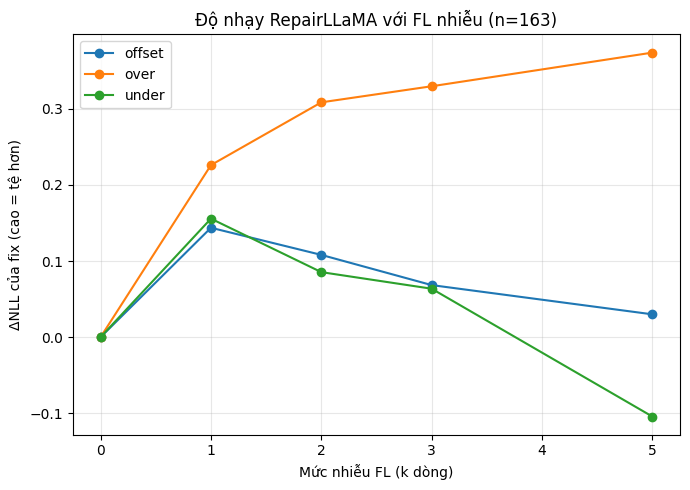

In [14]:
#Cell 14: Report
import json, numpy as np, matplotlib.pyplot as plt
sweep = json.load(open(f"{WORK}/nll_sweep.json"))
base = np.mean(list(sweep["perfect_0"].values()))      # NLL ở FL chuẩn

plt.figure(figsize=(7,5))
for mode in ("offset","over","under"):
    ks, ys = [0], [0.0]
    for k in (1,2,3,5):
        v = sweep.get(f"{mode}_{k}")
        if v:
            ks.append(k); ys.append(np.mean(list(v.values())) - base)
    plt.plot(ks, ys, marker="o", label=mode)
plt.xlabel("Mức nhiễu FL (k dòng)"); plt.ylabel("ΔNLL của fix (cao = tệ hơn)")
plt.title(f"Độ nhạy RepairLLaMA với FL nhiễu (n={len(sweep['perfect_0'])})")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(f"{WORK}/fl_robustness.png", dpi=150); plt.show()